### MBAI 5310G-001: AI Programming
Week 5 Assignment: Unsupervised Learning for Pattern Discovery

### Task 1: Understand the Business Problem
What is the main business problem? Why is customer/user segmentation useful for this business? What kind of marketing decisions could be improved by discovering customer/user groups?

Since the company receives many free sign-ups each month, the sales team cannot give every trial account the same level of attention. The data can help the business prioritize follow-up calls, onboarding support, discount offers, and customer success resources.

### Task 2: Prepare the Dataset

Converted_To_Paid is the target variable, there for is not used to train the K-means model. 

In [1]:
# Load the Dataset

import pandas as pd

# Load the Excel dataset
file_path = "../data/clouddesk_saas_trial_conversion_dataset.csv"
df = pd.read_csv(file_path)

# Display the first five rows
df.head()

,Trial_ID,Trial_Start_Date,Industry,Region,Lead_Source,Plan_Type,Company_Size,Trial_Length_Days,Login_Count_14_Days,Features_Used,...,Pricing_Pages_Viewed,Email_Clicks,Webinar_Attended,Support_Tickets,Discount_Offered_Percent,Competitor_Mentioned,Trial_Completion_Percent,Product_Fit_Score,Estimated_Annual_Value,Converted_To_Paid
0,TRIAL-10001,2026-04-06,Technology,Alberta,Organic Search,Enterprise,1-10,30,16.0,6,...,49,6.0,1,0,0,0,70.0,5.6,"$4,962",1
1,TRIAL-10002,2026-01-30,Technology,British Columbia,Paid Ads,Professional,1-10,14,13.0,5,...,36,4.0,0,0,10,1,82.0,5.4,"$5,173",0
2,TRIAL-10003,2026-03-04,Education,Quebec,Paid Ads,Enterprise,500+,21,15.0,8,...,43,5.0,0,2,10,0,100.0,8.8,"$27,163",1
3,TRIAL-10004,2026-01-15,Healthcare,Europe,Paid Ads,Professional,11-50,14,11.0,6,...,28,5.0,0,2,0,1,93.0,8.9,"$8,237",0
4,TRIAL-10005,2026-01-05,Education,British Columbia,Partner,Enterprise,51-200,30,20.0,8,...,52,5.0,0,1,15,0,100.0,5.7,"$15,070",1


In [2]:
# Check the number of rows and columns
df.shape
# Check column names
df.columns
# Check data types and general information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Trial_ID                  262 non-null    object 
 1   Trial_Start_Date          262 non-null    object 
 2   Industry                  262 non-null    object 
 3   Region                    260 non-null    object 
 4   Lead_Source               261 non-null    object 
 5   Plan_Type                 262 non-null    object 
 6   Company_Size              262 non-null    object 
 7   Trial_Length_Days         262 non-null    int64  
 8   Login_Count_14_Days       261 non-null    float64
 9   Features_Used             262 non-null    int64  
 10  Team_Invites              257 non-null    float64
 11  Pricing_Pages_Viewed      262 non-null    int64  
 12  Email_Clicks              259 non-null    float64
 13  Webinar_Attended          262 non-null    int64  
 14  Support_Ti

In [3]:
# Check missing values

df.isnull().sum()

Trial_ID                    0
Trial_Start_Date            0
Industry                    0
Region                      2
Lead_Source                 1
Plan_Type                   0
Company_Size                0
Trial_Length_Days           0
Login_Count_14_Days         1
Features_Used               0
Team_Invites                5
Pricing_Pages_Viewed        0
Email_Clicks                3
Webinar_Attended            0
Support_Tickets             0
Discount_Offered_Percent    0
Competitor_Mentioned        0
Trial_Completion_Percent    3
Product_Fit_Score           2
Estimated_Annual_Value      0
Converted_To_Paid           0
dtype: int64

In [4]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 2


In [5]:
# Show summary statistics for numerical columns

df.describe()

,Trial_Length_Days,Login_Count_14_Days,Features_Used,Team_Invites,Pricing_Pages_Viewed,Email_Clicks,Webinar_Attended,Support_Tickets,Discount_Offered_Percent,Competitor_Mentioned,Trial_Completion_Percent,Product_Fit_Score,Converted_To_Paid
count,262.000000,261.000000,262.000000,257.000000,262.000000,259.000000,262.000000,262.000000,262.000000,262.000000,259.000000,260.000000,262.000000
mean,21.736641,10.498084,4.709924,2.338521,27.816794,2.791506,0.312977,1.171756,9.828244,0.183206,72.316602,6.019231,0.412214
std,6.153474,5.212872,2.353732,2.171863,12.026026,2.006522,0.464593,1.081490,7.470830,0.387576,23.158373,1.980117,0.493175
min,14.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,14.000000,7.000000,3.000000,0.000000,20.000000,1.000000,0.000000,0.000000,5.000000,0.000000,57.000000,4.600000,0.000000
50%,21.000000,10.000000,5.000000,2.000000,27.000000,3.000000,0.000000,1.000000,10.000000,0.000000,74.000000,6.000000,0.000000
75%,30.000000,14.000000,6.000000,4.000000,36.000000,4.000000,1.000000,2.000000,15.000000,0.000000,94.000000,7.525000,1.000000
max,30.000000,26.000000,11.000000,9.000000,63.000000,9.000000,1.000000,4.000000,20.000000,1.000000,100.000000,10.000000,1.000000


### Dataset Inspection

In [6]:
# Create a copy of the original dataset
df_clean = df.copy()

# Clean column names by removing extra spaces
df_clean.columns = df_clean.columns.str.strip()

# Display original shape
print("Original dataset shape:", df_clean.shape)

Original dataset shape: (262, 21)


In [7]:
# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

print("Dataset shape after removing duplicates:", df_clean.shape)

Dataset shape after removing duplicates: (260, 21)


In [8]:
# Check missing values after removing duplicates

df_clean.isnull().sum()

Trial_ID                    0
Trial_Start_Date            0
Industry                    0
Region                      2
Lead_Source                 1
Plan_Type                   0
Company_Size                0
Trial_Length_Days           0
Login_Count_14_Days         1
Features_Used               0
Team_Invites                5
Pricing_Pages_Viewed        0
Email_Clicks                3
Webinar_Attended            0
Support_Tickets             0
Discount_Offered_Percent    0
Competitor_Mentioned        0
Trial_Completion_Percent    3
Product_Fit_Score           1
Estimated_Annual_Value      0
Converted_To_Paid           0
dtype: int64

In [9]:
numerical_columns = [
    "Trial_Length_Days",
    "Login_Count_14_Days",
    "Features_Used",
    "Team_Invites",
    "Pricing_Pages_Viewed",
    "Email_Clicks",
    "Webinar_Attended",
    "Support_Tickets",
    "Discount_Offered_Percent",
    "Competitor_Mentioned",
    "Trial_Completion_Percent",
    "Product_Fit_Score",
    "Estimated_Annual_Value"
]

X = df_clean[numerical_columns]

# Display selected features
X.head()

,Trial_Length_Days,Login_Count_14_Days,Features_Used,Team_Invites,Pricing_Pages_Viewed,Email_Clicks,Webinar_Attended,Support_Tickets,Discount_Offered_Percent,Competitor_Mentioned,Trial_Completion_Percent,Product_Fit_Score,Estimated_Annual_Value
0,30,16.0,6,0.0,49,6.0,1,0,0,0,70.0,5.6,"$4,962"
1,14,13.0,5,2.0,36,4.0,0,0,10,1,82.0,5.4,"$5,173"
2,21,15.0,8,6.0,43,5.0,0,2,10,0,100.0,8.8,"$27,163"
3,14,11.0,6,3.0,28,5.0,0,2,0,1,93.0,8.9,"$8,237"
4,30,20.0,8,5.0,52,5.0,0,1,15,0,100.0,5.7,"$15,070"


In [10]:
print("Features selected for clustering:")
for feature in numerical_columns:
    print("-", feature)

Features selected for clustering:
- Trial_Length_Days
- Login_Count_14_Days
- Features_Used
- Team_Invites
- Pricing_Pages_Viewed
- Email_Clicks
- Webinar_Attended
- Support_Tickets
- Discount_Offered_Percent
- Competitor_Mentioned
- Trial_Completion_Percent
- Product_Fit_Score
- Estimated_Annual_Value


In [11]:
for col in numerical_columns:
    df_clean[col] = (
        df_clean[col]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.strip()
    )

    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

    # Fill missing values after converting to numeric
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
df_clean.isnull().sum()

Trial_ID                    0
Trial_Start_Date            0
Industry                    0
Region                      2
Lead_Source                 1
Plan_Type                   0
Company_Size                0
Trial_Length_Days           0
Login_Count_14_Days         0
Features_Used               0
Team_Invites                0
Pricing_Pages_Viewed        0
Email_Clicks                0
Webinar_Attended            0
Support_Tickets             0
Discount_Offered_Percent    0
Competitor_Mentioned        0
Trial_Completion_Percent    0
Product_Fit_Score           0
Estimated_Annual_Value      0
Converted_To_Paid           0
dtype: int64

In [12]:
X = df_clean[numerical_columns]

# Confirm that there are no missing values in X
X.isnull().sum()

Trial_Length_Days           0
Login_Count_14_Days         0
Features_Used               0
Team_Invites                0
Pricing_Pages_Viewed        0
Email_Clicks                0
Webinar_Attended            0
Support_Tickets             0
Discount_Offered_Percent    0
Competitor_Mentioned        0
Trial_Completion_Percent    0
Product_Fit_Score           0
Estimated_Annual_Value      0
dtype: int64

In [13]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Scale the selected features
X_scaled = scaler.fit_transform(X)

# Convert scaled data back to a DataFrame for better readability
X_scaled_df = pd.DataFrame(X_scaled, columns=numerical_columns)

X_scaled_df.head()

,Trial_Length_Days,Login_Count_14_Days,Features_Used,Team_Invites,Pricing_Pages_Viewed,Email_Clicks,Webinar_Attended,Support_Tickets,Discount_Offered_Percent,Competitor_Mentioned,Trial_Completion_Percent,Product_Fit_Score,Estimated_Annual_Value
0,1.339133,1.062851,0.550722,-1.095167,1.764726,1.610841,1.47334,-1.080326,-1.321959,-0.475831,-0.101944,-0.211553,-0.018969
1,-1.264041,0.485537,0.125833,-0.163110,0.683563,0.608882,-0.67873,-1.080326,0.023283,2.101587,0.421189,-0.312756,0.019908
2,-0.125153,0.870413,1.400501,1.701004,1.265728,1.109862,-0.67873,0.767600,0.023283,-0.475831,1.205888,1.407693,4.071585
3,-1.264041,0.100660,0.550722,0.302918,0.018233,1.109862,-0.67873,0.767600,-1.321959,2.101587,0.900727,1.458294,0.584453
4,1.339133,1.832605,1.400501,1.234975,2.014225,1.109862,-0.67873,-0.156363,0.695904,-0.475831,1.205888,-0.160951,1.843439


In [14]:
print("Mean after scaling:")
print(X_scaled_df.mean().round(2))

print()
print("Standard deviation after scaling:")
print(X_scaled_df.std().round(2))

Mean after scaling:
Trial_Length_Days          -0.0
Login_Count_14_Days        -0.0
Features_Used              -0.0
Team_Invites               -0.0
Pricing_Pages_Viewed        0.0
Email_Clicks                0.0
Webinar_Attended            0.0
Support_Tickets            -0.0
Discount_Offered_Percent    0.0
Competitor_Mentioned        0.0
Trial_Completion_Percent   -0.0
Product_Fit_Score          -0.0
Estimated_Annual_Value      0.0
dtype: float64

Standard deviation after scaling:
Trial_Length_Days           1.0
Login_Count_14_Days         1.0
Features_Used               1.0
Team_Invites                1.0
Pricing_Pages_Viewed        1.0
Email_Clicks                1.0
Webinar_Attended            1.0
Support_Tickets             1.0
Discount_Offered_Percent    1.0
Competitor_Mentioned        1.0
Trial_Completion_Percent    1.0
Product_Fit_Score           1.0
Estimated_Annual_Value      1.0
dtype: float64


### Task 3: Apply K-means Clustering

E:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
E:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
E:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
E:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

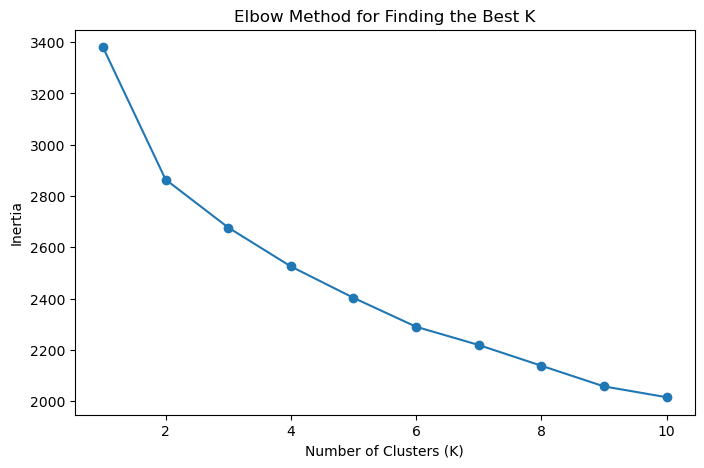

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Finding the Best K")
plt.show()

In [16]:
elbow_results = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertia
})

elbow_results

,K,Inertia
0,1,3380.000000
1,2,2864.485556
2,3,2677.329700
3,4,2525.816877
4,5,2403.454410
5,6,2290.694934
6,7,2219.540950
7,8,2138.749561
8,9,2058.240738
9,10,2016.032296


### Analysis of the Elbow Method

I selected K = 3 because the decrease is strongest in the first few cluster values and becomes more gradual after about K = 3.

In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

cluster_labels = kmeans.fit_predict(X_scaled)

cluster_labels[:10]

E:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


array([2, 0, 0, 0, 0, 0, 0, 1, 2, 0], dtype=int32)

In [18]:
pd.Series(cluster_labels).value_counts().sort_index()

0     96
1    101
2     63
Name: count, dtype: int64

In [19]:
df_clustered = df_clean.copy()

df_clustered["Cluster"] = cluster_labels

df_clustered.head()

,Trial_ID,Trial_Start_Date,Industry,Region,Lead_Source,Plan_Type,Company_Size,Trial_Length_Days,Login_Count_14_Days,Features_Used,...,Email_Clicks,Webinar_Attended,Support_Tickets,Discount_Offered_Percent,Competitor_Mentioned,Trial_Completion_Percent,Product_Fit_Score,Estimated_Annual_Value,Converted_To_Paid,Cluster
0,TRIAL-10001,2026-04-06,Technology,Alberta,Organic Search,Enterprise,1-10,30,16.0,6,...,6.0,1,0,0,0,70.0,5.6,4962,1,2
1,TRIAL-10002,2026-01-30,Technology,British Columbia,Paid Ads,Professional,1-10,14,13.0,5,...,4.0,0,0,10,1,82.0,5.4,5173,0,0
2,TRIAL-10003,2026-03-04,Education,Quebec,Paid Ads,Enterprise,500+,21,15.0,8,...,5.0,0,2,10,0,100.0,8.8,27163,1,0
3,TRIAL-10004,2026-01-15,Healthcare,Europe,Paid Ads,Professional,11-50,14,11.0,6,...,5.0,0,2,0,1,93.0,8.9,8237,0,0
4,TRIAL-10005,2026-01-05,Education,British Columbia,Partner,Enterprise,51-200,30,20.0,8,...,5.0,0,1,15,0,100.0,5.7,15070,1,0


In [20]:
df_clustered[
    [
        "Trial_ID",
        "Login_Count_14_Days",
        "Features_Used",
        "Pricing_Pages_Viewed",
        "Trial_Completion_Percent",
        "Product_Fit_Score",
        "Estimated_Annual_Value",
        "Converted_To_Paid",
        "Cluster"
    ]
].head(10)

,Trial_ID,Login_Count_14_Days,Features_Used,Pricing_Pages_Viewed,Trial_Completion_Percent,Product_Fit_Score,Estimated_Annual_Value,Converted_To_Paid,Cluster
0,TRIAL-10001,16.0,6,49,70.0,5.6,4962,1,2
1,TRIAL-10002,13.0,5,36,82.0,5.4,5173,0,0
2,TRIAL-10003,15.0,8,43,100.0,8.8,27163,1,0
3,TRIAL-10004,11.0,6,28,93.0,8.9,8237,0,0
4,TRIAL-10005,20.0,8,52,100.0,5.7,15070,1,0
5,TRIAL-10006,16.0,6,25,100.0,6.5,7406,1,0
6,TRIAL-10007,19.0,6,63,100.0,6.5,5325,1,0
7,TRIAL-10008,7.0,3,30,70.0,10.0,7869,0,1
8,TRIAL-10009,8.0,3,25,75.0,7.3,4005,1,2
9,TRIAL-10010,15.0,6,35,78.0,3.4,11770,0,0


### Task 4: Analyze and Interpret the Clusters

In [21]:
# Calculate the average value of each feature for each cluster
cluster_summary = df_clustered.groupby("Cluster")[numerical_columns].mean()

cluster_summary_rounded = cluster_summary.round(2)

cluster_summary_rounded

,Trial_Length_Days,Login_Count_14_Days,Features_Used,Team_Invites,Pricing_Pages_Viewed,Email_Clicks,Webinar_Attended,Support_Tickets,Discount_Offered_Percent,Competitor_Mentioned,Trial_Completion_Percent,Product_Fit_Score,Estimated_Annual_Value
Cluster,,,,,,,,,,,,,
0,21.29,14.47,6.34,2.84,36.08,3.41,0.01,1.34,10.05,0.18,86.94,6.07,7366.58
1,22.10,6.02,3.04,2.03,18.82,2.11,0.18,1.07,9.70,0.17,55.07,5.52,2997.35
2,21.97,11.54,4.87,2.11,29.49,2.92,1.00,1.06,9.68,0.22,77.78,6.74,4872.43


In [22]:
cluster_counts = df_clustered["Cluster"].value_counts().sort_index()
conversion_rate = df_clustered.groupby("Cluster")["Converted_To_Paid"].mean().round(2)

cluster_summary_final = cluster_summary_rounded.copy()
cluster_summary_final["Number_of_Trial_Accounts"] = cluster_counts
cluster_summary_final["Conversion_Rate_For_Reference"] = conversion_rate

cluster_summary_final

,Trial_Length_Days,Login_Count_14_Days,Features_Used,Team_Invites,Pricing_Pages_Viewed,Email_Clicks,Webinar_Attended,Support_Tickets,Discount_Offered_Percent,Competitor_Mentioned,Trial_Completion_Percent,Product_Fit_Score,Estimated_Annual_Value,Number_of_Trial_Accounts,Conversion_Rate_For_Reference
Cluster,,,,,,,,,,,,,,,
0,21.29,14.47,6.34,2.84,36.08,3.41,0.01,1.34,10.05,0.18,86.94,6.07,7366.58,96,0.62
1,22.10,6.02,3.04,2.03,18.82,2.11,0.18,1.07,9.70,0.17,55.07,5.52,2997.35,101,0.10
2,21.97,11.54,4.87,2.11,29.49,2.92,1.00,1.06,9.68,0.22,77.78,6.74,4872.43,63,0.60


In [23]:


summary = cluster_summary_final.copy()

low_engagement_cluster = summary["Login_Count_14_Days"].idxmin()

high_value_cluster = summary.drop(index=low_engagement_cluster)["Estimated_Annual_Value"].idxmax()

webinar_fit_cluster = summary.drop(index=[low_engagement_cluster, high_value_cluster]).index[0]

segment_names = {
    high_value_cluster: "High-Value Engaged Trial Accounts",
    low_engagement_cluster: "Low-Engagement Trial Accounts",
    webinar_fit_cluster: "Medium-Engagement Trial Accounts"
}

df_clustered["Segment_Name"] = df_clustered["Cluster"].map(segment_names)

segment_mapping = pd.DataFrame({
    "Cluster": list(segment_names.keys()),
    "Segment_Name": list(segment_names.values())
}).sort_values("Cluster")

segment_mapping

,Cluster,Segment_Name
0,0,High-Value Engaged Trial Accounts
1,1,Low-Engagement Trial Accounts
2,2,Medium-Engagement Trial Accounts


In [24]:
segment_interpretation = pd.DataFrame({
    "Segment Name": [
        "High-Value Engaged Trial Accounts",
        "Low-Engagement Trial Accounts",
        "Medium-Engagement Trial Accounts"
    ],
    "Main Characteristics": [
        "High login activity, more features used, many pricing page views, high trial completion, and the highest estimated annual value.",
        "Lowest login activity, fewer features used, lower pricing interest, lower trial completion, and the lowest conversion rate.",
        "Medium login activity compared with the High-Value Engaged Trial Accounts, similar to the High-Value Engaged Trial Accounts but with the highest product-fit score"
    ],
    "Business Meaning": [
        "This segment is the most valuable, combining strong engagement with the highest revenue potential.",
        "This segment should receive less attention because they have the lowest Product_Fit_Score.",
        "This segment product interest and likely responsiveness to onboarding and sales education."
    ]
})

segment_interpretation

,Segment Name,Main Characteristics,Business Meaning
0,High-Value Engaged Trial Accounts,"High login activity, more features used, many ...","This segment is the most valuable, combining s..."
1,Low-Engagement Trial Accounts,"Lowest login activity, fewer features used, lo...",This segment should receive less attention bec...
2,Medium-Engagement Trial Accounts,Medium login activity compared with the High-V...,This segment product interest and likely respo...


In [25]:
# Check how many trial accounts are in each named segment

df_clustered["Segment_Name"].value_counts()

Segment_Name
Low-Engagement Trial Accounts        101
High-Value Engaged Trial Accounts     96
Medium-Engagement Trial Accounts      63
Name: count, dtype: int64

In [26]:
# Calculate average values for each business segment

business_segment_summary = df_clustered.groupby("Segment_Name")[
    [
        "Login_Count_14_Days",
        "Features_Used",
        "Pricing_Pages_Viewed",
        "Trial_Completion_Percent",
        "Product_Fit_Score",
        "Estimated_Annual_Value",
        "Converted_To_Paid"
    ]
].mean().round(2)

business_segment_summary

,Login_Count_14_Days,Features_Used,Pricing_Pages_Viewed,Trial_Completion_Percent,Product_Fit_Score,Estimated_Annual_Value,Converted_To_Paid
Segment_Name,,,,,,,
High-Value Engaged Trial Accounts,14.47,6.34,36.08,86.94,6.07,7366.58,0.62
Low-Engagement Trial Accounts,6.02,3.04,18.82,55.07,5.52,2997.35,0.10
Medium-Engagement Trial Accounts,11.54,4.87,29.49,77.78,6.74,4872.43,0.60


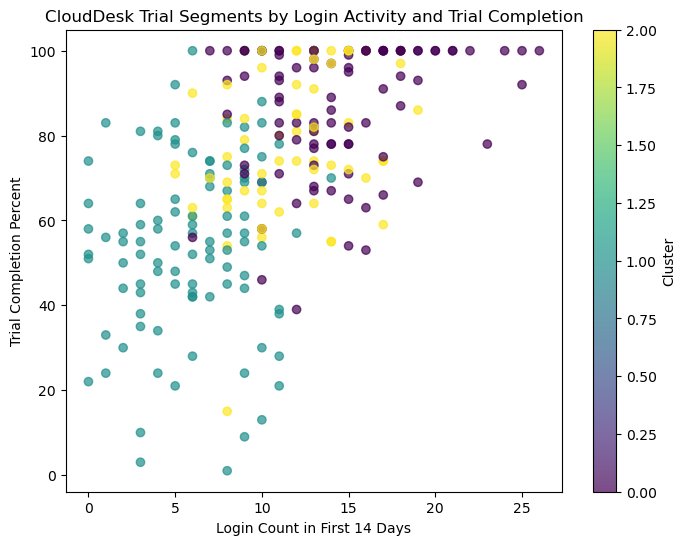

In [27]:
# Step 15: Scatter Plot Using Two Selected Features

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    df_clustered["Login_Count_14_Days"],
    df_clustered["Trial_Completion_Percent"],
    c=df_clustered["Cluster"],
    alpha=0.7
)

plt.xlabel("Login Count in First 14 Days")
plt.ylabel("Trial Completion Percent")
plt.title("CloudDesk Trial Segments by Login Activity and Trial Completion")
plt.colorbar(label="Cluster")
plt.show()

### Bar Chart

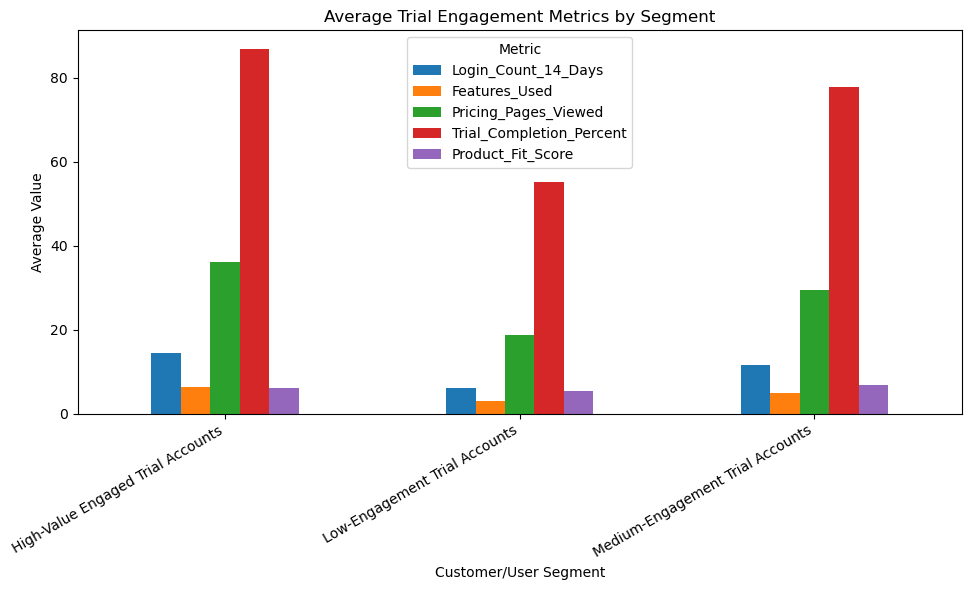

In [28]:
metrics_to_compare = [
    "Login_Count_14_Days",
    "Features_Used",
    "Pricing_Pages_Viewed",
    "Trial_Completion_Percent",
    "Product_Fit_Score"
]

segment_avg = df_clustered.groupby("Segment_Name")[metrics_to_compare].mean().round(2)

segment_avg.plot(kind="bar", figsize=(10, 6))
plt.xlabel("Customer/User Segment")
plt.ylabel("Average Value")
plt.title("Average Trial Engagement Metrics by Segment")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

### Box Plot 

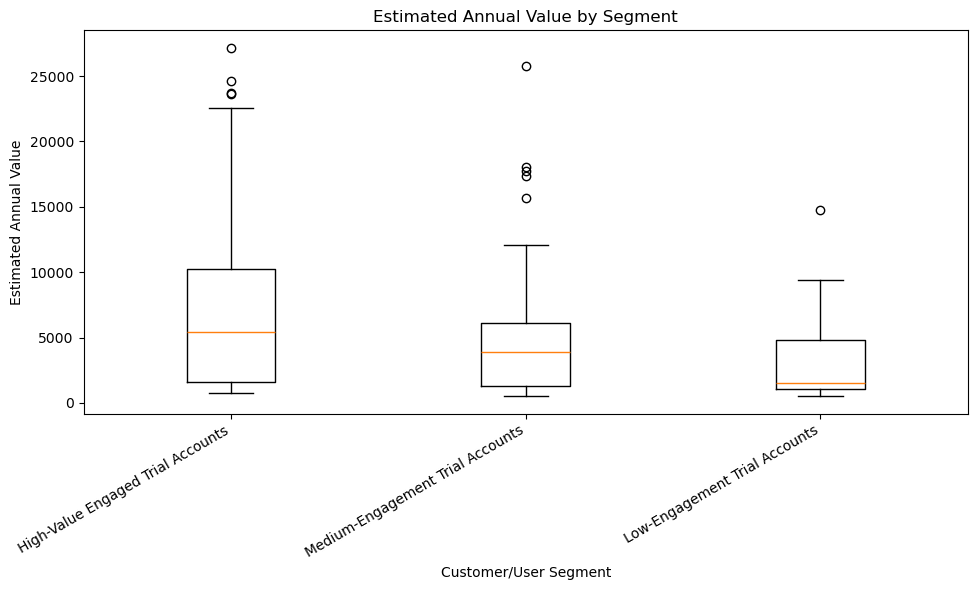

In [29]:
segment_order = [
    "High-Value Engaged Trial Accounts",
    "Medium-Engagement Trial Accounts",
    "Low-Engagement Trial Accounts"
]

boxplot_data = [
    df_clustered[df_clustered["Segment_Name"] == segment]["Estimated_Annual_Value"]
    for segment in segment_order
]

plt.figure(figsize=(10, 6))
plt.boxplot(boxplot_data, tick_labels=segment_order)
plt.xlabel("Customer/User Segment")
plt.ylabel("Estimated Annual Value")
plt.title("Estimated Annual Value by Segment")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [30]:

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df_clustered["PCA1"] = X_pca[:, 0]
df_clustered["PCA2"] = X_pca[:, 1]

df_clustered[["Trial_ID", "Cluster", "Segment_Name", "PCA1", "PCA2"]].head()

,Trial_ID,Cluster,Segment_Name,PCA1,PCA2
0,TRIAL-10001,2,Medium-Engagement Trial Accounts,1.424847,1.443257
1,TRIAL-10002,0,High-Value Engaged Trial Accounts,0.783292,0.943609
2,TRIAL-10003,0,High-Value Engaged Trial Accounts,4.121647,-0.145210
3,TRIAL-10004,0,High-Value Engaged Trial Accounts,1.537680,-0.588414
4,TRIAL-10005,0,High-Value Engaged Trial Accounts,3.816991,1.386696


### PCA Visualization

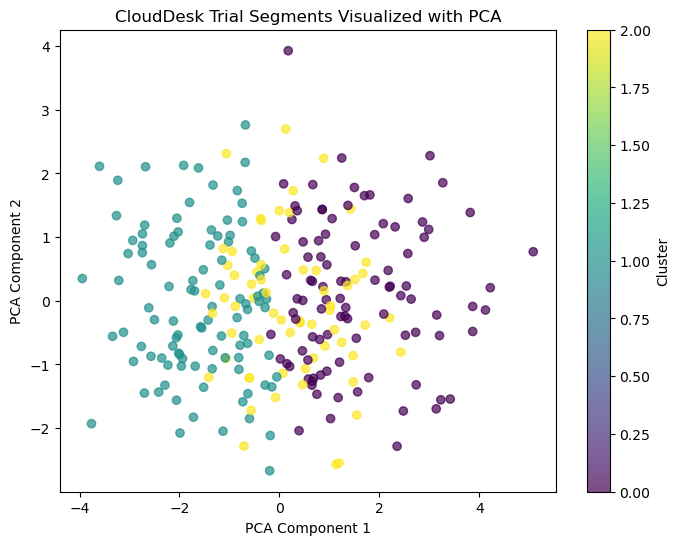

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_clustered["PCA1"],
    df_clustered["PCA2"],
    c=df_clustered["Cluster"],
    alpha=0.7
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("CloudDesk Trial Segments Visualized with PCA")
plt.colorbar(label="Cluster")
plt.show()

In [32]:
explained_variance = pca.explained_variance_ratio_

print("Explained variance by PCA1:", round(explained_variance[0], 3))
print("Explained variance by PCA2:", round(explained_variance[1], 3))
print("Total explained variance:", round(explained_variance.sum(), 3))

Explained variance by PCA1: 0.229
Explained variance by PCA2: 0.101
Total explained variance: 0.331


### Task 6: Business Interpretation and Recommendation

High-Value Engaged Trial Accounts and Medium-Engagement Trial Accounts should receive the most direct sales attention because they show strong engagement and high estimated annual value.

Low-Engagement Trial Accounts should receive less attention because they have the lowest Product_Fit_Score.

This analysis can help CloudDesk make better decisions by prioritizing accounts, creating segment-specific campaigns, forecasting conversion potential, and allocating customer success resources more efficiently.

### Task 7: Limitations and Responsible AI Reflection



#### What is one limitation of the dataset or model?
The dataset may not include all real sales factors such as budget timing, buying committees, or relationship quality. 
#### Why does K-means not always produce perfect customer segments?
Real customers may overlap across groups, so cluster boundaries are not perfect business rules. In this cause High-Value Engaged Trial Accounts and Medium-Engagement Trial Accounts overlap a lot.
#### What unfair decision could happen without human review?
Trial accounts with low engagement may be judged as low-value customers by the system, resulting in fewer sales follow-ups, discounts, or customer support. However, some customers may simply need more time to learn about the product or may not be actively using it due to a lack of training.
#### Why should human judgment still be used?
Human judgment is needed to review customer context, avoid unfair treatment, and make practical marketing decisions that a model cannot fully understand.